In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Visualization settings
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup complete")

✅ Setup complete


## 1. Data Loading and Preprocessing

In [2]:
# Load data
df = pd.read_csv('final.csv')
df.drop(['matchId','gameDuration'], axis=1, inplace=True)

print(f"Total data: {len(df):,}")
print(f"Variables: {len(df.columns)}")
print(f"\nWin/Loss ratio:")
print(df['blueWins'].value_counts(normalize=True))

Total data: 94,355
Variables: 41

Win/Loss ratio:
blueWins
0    0.536442
1    0.463558
Name: proportion, dtype: float64


In [3]:
# Apply data filtering (same as ftest.ipynb)
df_clean = df.copy()
start_len = len(df_clean)

# Gold filtering
mask_gold = (df_clean['blueTotalGold'] > 20000) & (df_clean['redTotalGold'] > 20000)
df_clean = df_clean[mask_gold]
gold_removed = start_len - len(df_clean)

# Jungle minion filtering
mask_jungle = (df_clean['blueTotalJungleMinionsKilled'] > 0) & (df_clean['redTotalJungleMinionsKilled'] > 0)
df_clean = df_clean[mask_jungle]
jungle_removed = start_len - gold_removed - len(df_clean)

# Ward filtering
mask_ward = (df_clean['blueWardsPlaced'] <= 400) & (df_clean['redWardsPlaced'] <= 400)
df_clean = df_clean[mask_ward]
ward_removed = start_len - gold_removed - jungle_removed - len(df_clean)

print(f"Original: {start_len:,}")
print(f"After cleaning: {len(df_clean):,} ({len(df_clean)/start_len*100:.2f}%)")
print(f"Removed: {start_len - len(df_clean):,}")

Original: 94,355
After cleaning: 94,180 (99.81%)
Removed: 175


## 2. Variable Definitions and Basic Statistics

In [4]:
# Variable groups
target_vars = [
    ('Growth', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('Growth', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('Growth', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('Growth', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('Combat', 'Kills', 'blueKills', 'redKills'),
    ('Combat', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('Combat', 'Assists', 'blueAssists', 'redAssists'),
    ('Combat', 'FirstBlood', 'blueFirstBlood', 'redFirstBlood'),
    ('Objective', 'Dragons', 'blueDragons', 'redDragons'),
    ('Objective', 'FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('Objective', 'Heralds', 'blueHeralds', 'redHeralds'),
    ('Objective', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('Structure', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('Structure', 'FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('Structure', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('Structure', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    ('Vision', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('Vision', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('Vision', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('Vision', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed')
]

categories = ['Growth', 'Combat', 'Objective', 'Structure', 'Vision']
category_colors = {
    'Growth': '#FF6B6B',
    'Combat': '#4ECDC4',
    'Objective': '#FFE66D',
    'Structure': '#95E1D3',
    'Vision': '#C7CEEA'
}

# Calculate statistics
results = []
for category, name, b_col, r_col in target_vars:
    if b_col in df_clean.columns:
        winner_vals = np.where(df_clean['blueWins'] == 1, df_clean[b_col], df_clean[r_col])
        loser_vals = np.where(df_clean['blueWins'] == 1, df_clean[r_col], df_clean[b_col])
        
        t_stat, p_val = stats.ttest_ind(winner_vals, loser_vals, equal_var=False)
        
        results.append({
            'Category': category,
            'Variable': name,
            'Winner_Mean': np.mean(winner_vals),
            'Loser_Mean': np.mean(loser_vals),
            'T-value': t_stat,
            'blue_col': b_col,
            'red_col': r_col
        })

stats_df = pd.DataFrame(results)
print("\n=== Basic Statistics ===")
print(stats_df[['Category', 'Variable', 'Winner_Mean', 'Loser_Mean', 'T-value']].to_string(index=False))


=== Basic Statistics ===
 Category                 Variable  Winner_Mean   Loser_Mean     T-value
   Growth                TotalGold 29548.550764 26948.320525  242.537872
   Growth          TotalExperience 31251.215470 29524.768199  229.336660
   Growth       TotalMinionsKilled   377.529051   361.079051  120.188747
   Growth TotalJungleMinionsKilled    92.412136    86.197983   97.311102
   Combat                    Kills    14.525281    10.702633  187.181885
   Combat                   Deaths    10.702633    14.525281 -187.181885
   Combat                  Assists    17.275526    12.707581  150.064163
   Combat               FirstBlood     0.585337     0.414663   75.175552
Objective                  Dragons     0.957316     0.550372  128.154518
Objective              FirstDragon     0.604810     0.377925  101.121025
Objective                  Heralds     0.190147     0.098800   56.834388
Objective                VoidGrubs     3.224018     2.494872   76.039140
Structure          Towers

## 3. Winner vs Loser Mean Comparison by Category

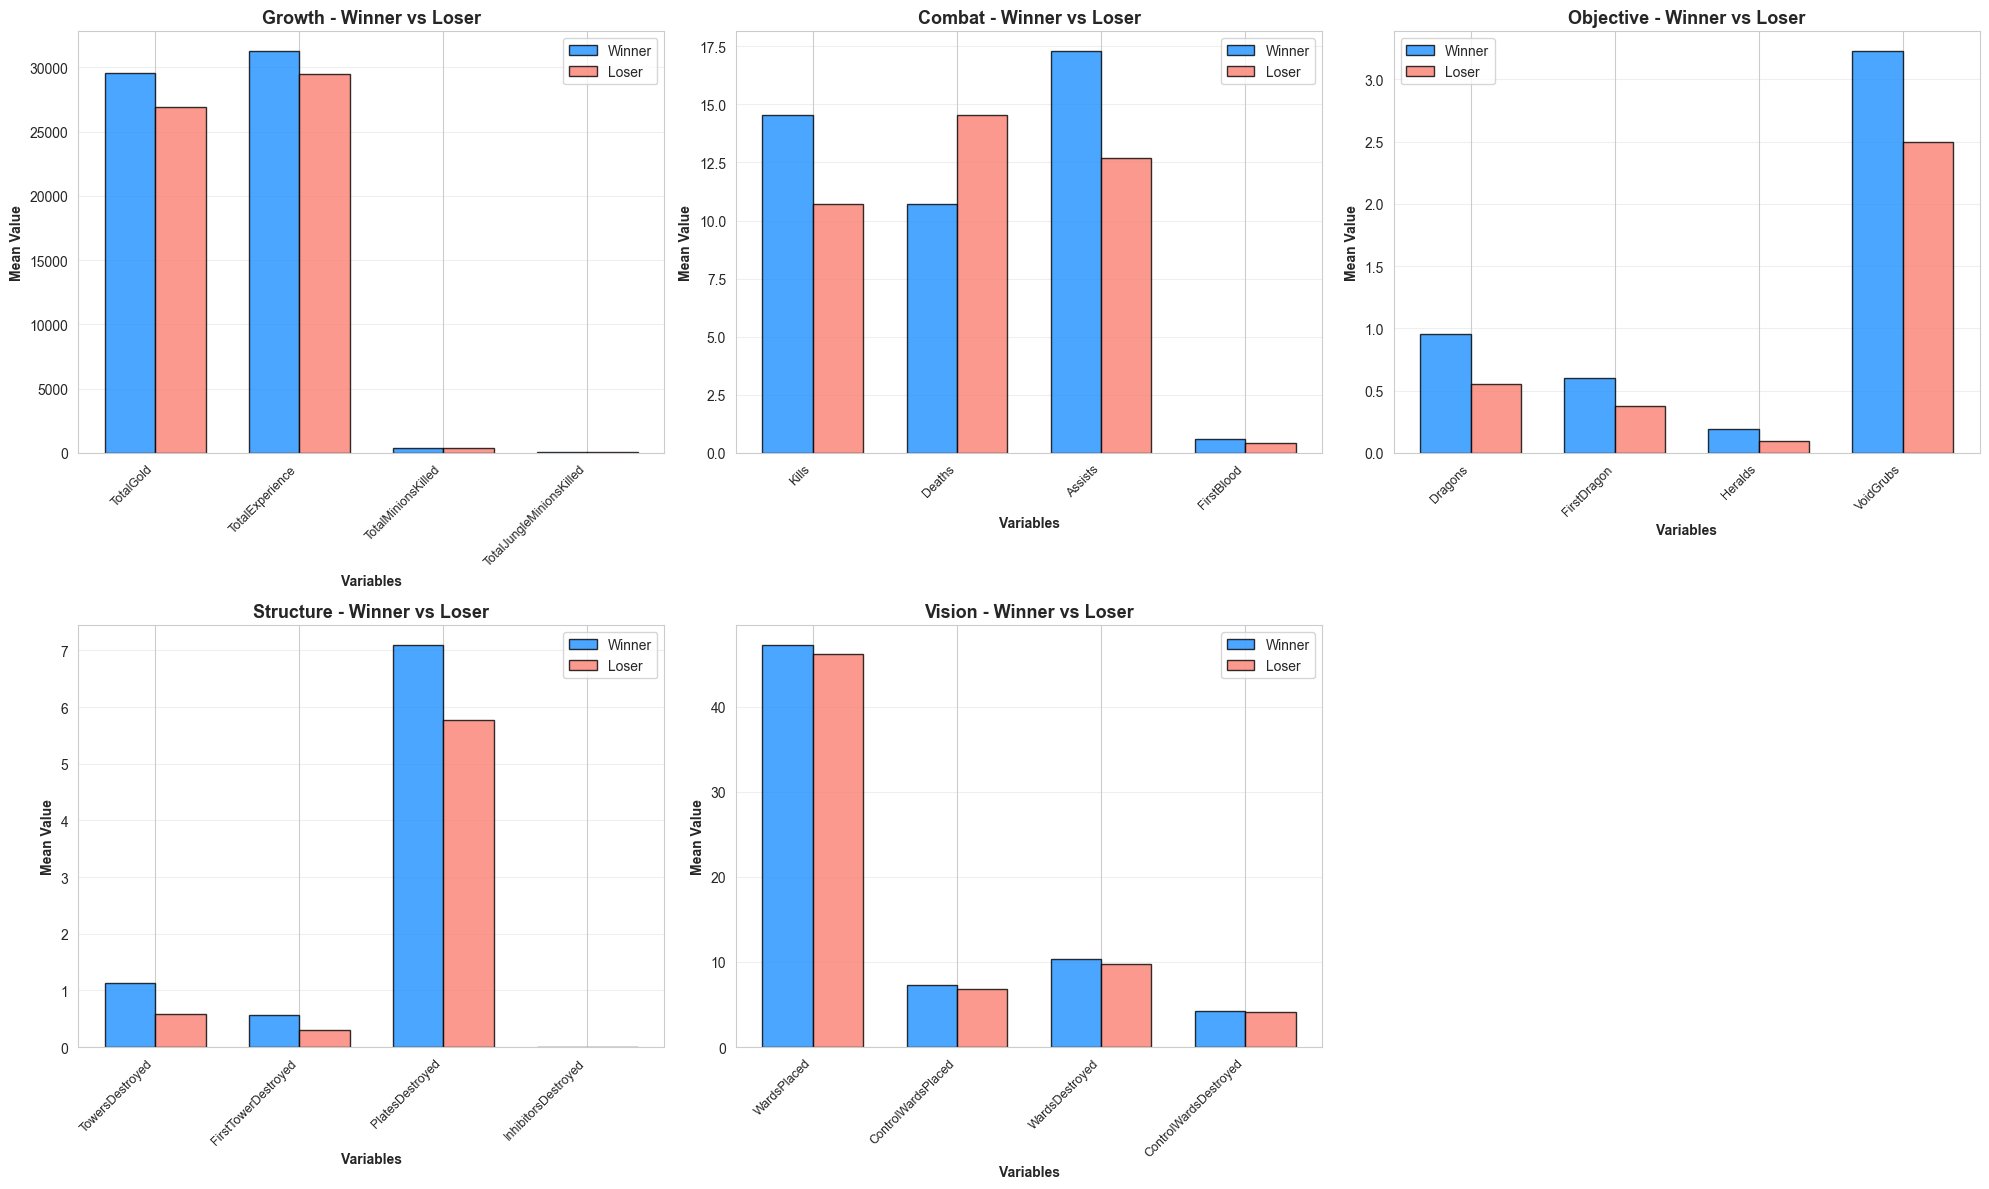

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, category in enumerate(categories):
    ax = axes[idx]
    cat_data = stats_df[stats_df['Category'] == category]
    
    x = np.arange(len(cat_data))
    width = 0.35
    
    ax.bar(x - width/2, cat_data['Winner_Mean'], width, 
           label='Winner', color='dodgerblue', alpha=0.8, edgecolor='black')
    ax.bar(x + width/2, cat_data['Loser_Mean'], width,
           label='Loser', color='salmon', alpha=0.8, edgecolor='black')
    
    ax.set_xlabel('Variables', fontweight='bold')
    ax.set_ylabel('Mean Value', fontweight='bold')
    ax.set_title(f'{category} - Winner vs Loser', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cat_data['Variable'], rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 4. T-value Ranking (Top 15)

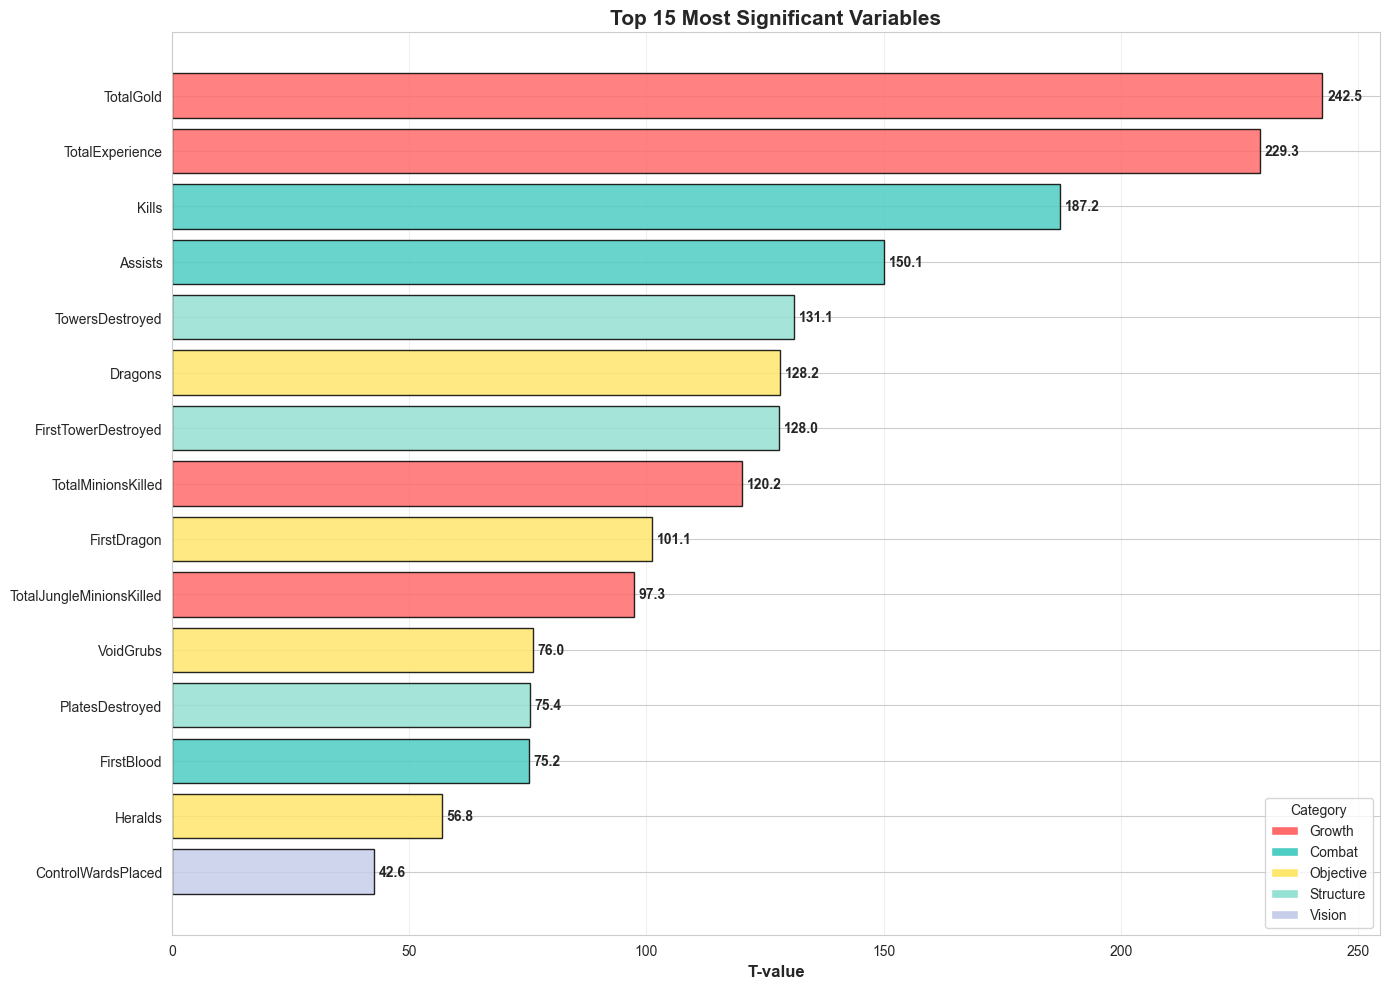

In [6]:
top15 = stats_df.nlargest(15, 'T-value')

fig, ax = plt.subplots(figsize=(14, 10))
colors = [category_colors[cat] for cat in top15['Category']]
bars = ax.barh(top15['Variable'], top15['T-value'], color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('T-value', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Significant Variables', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for bar, tval in zip(bars, top15['T-value']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{tval:.1f}', va='center', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=category_colors[cat], label=cat) for cat in categories]
ax.legend(handles=legend_elements, loc='lower right', title='Category')

plt.tight_layout()
plt.show()

## 5. Distribution Boxplots by Category

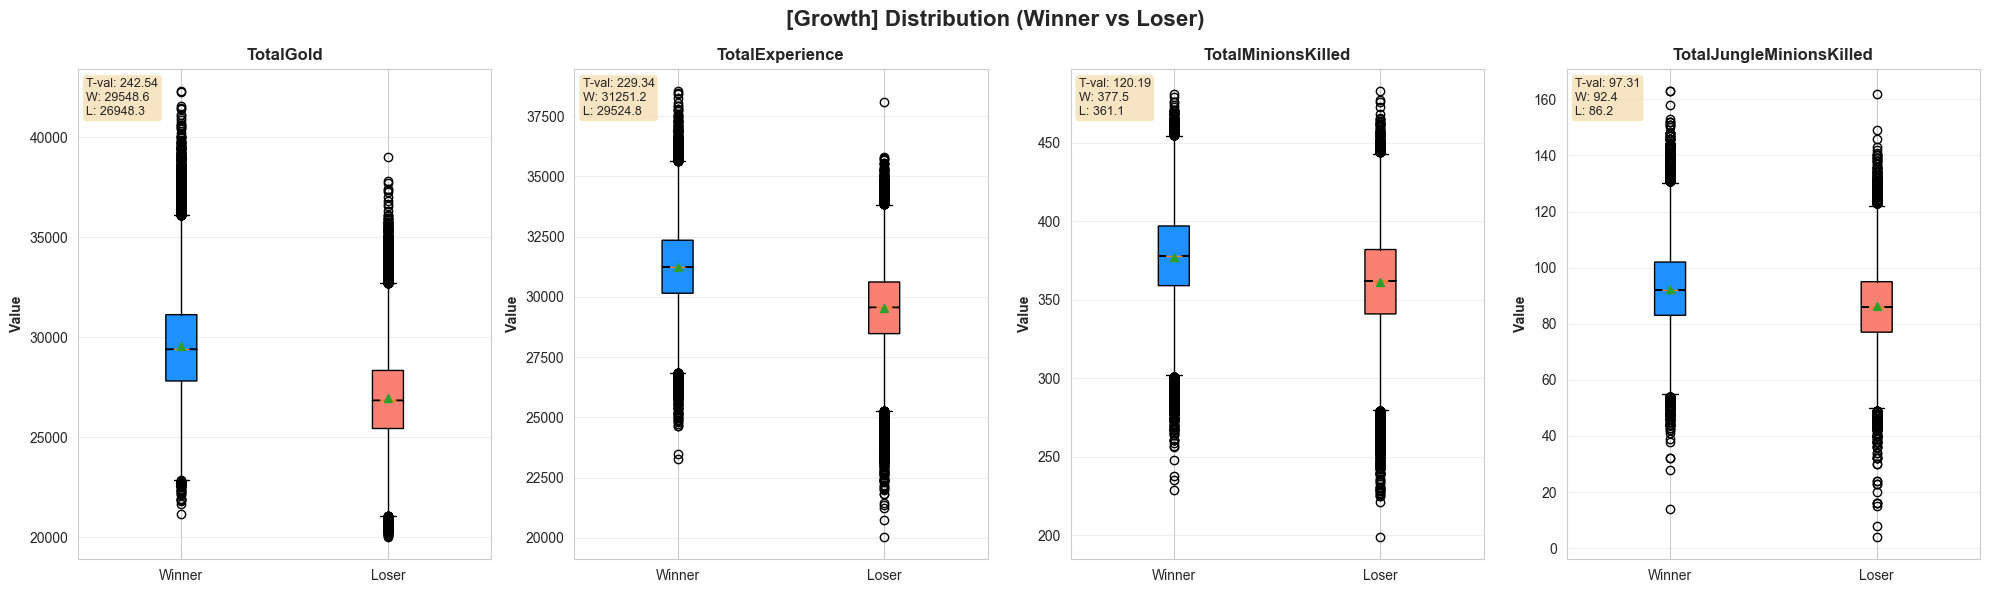

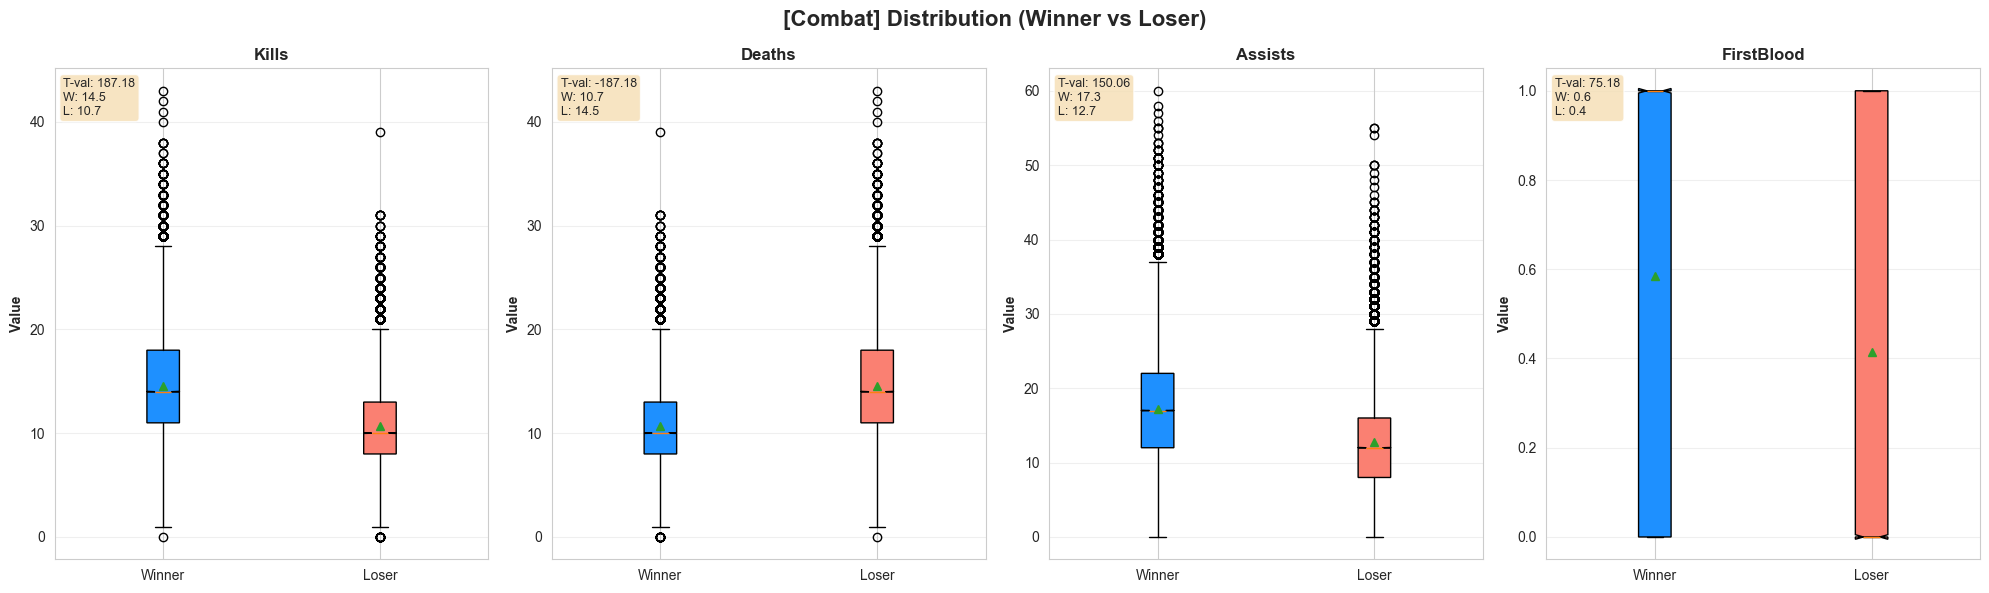

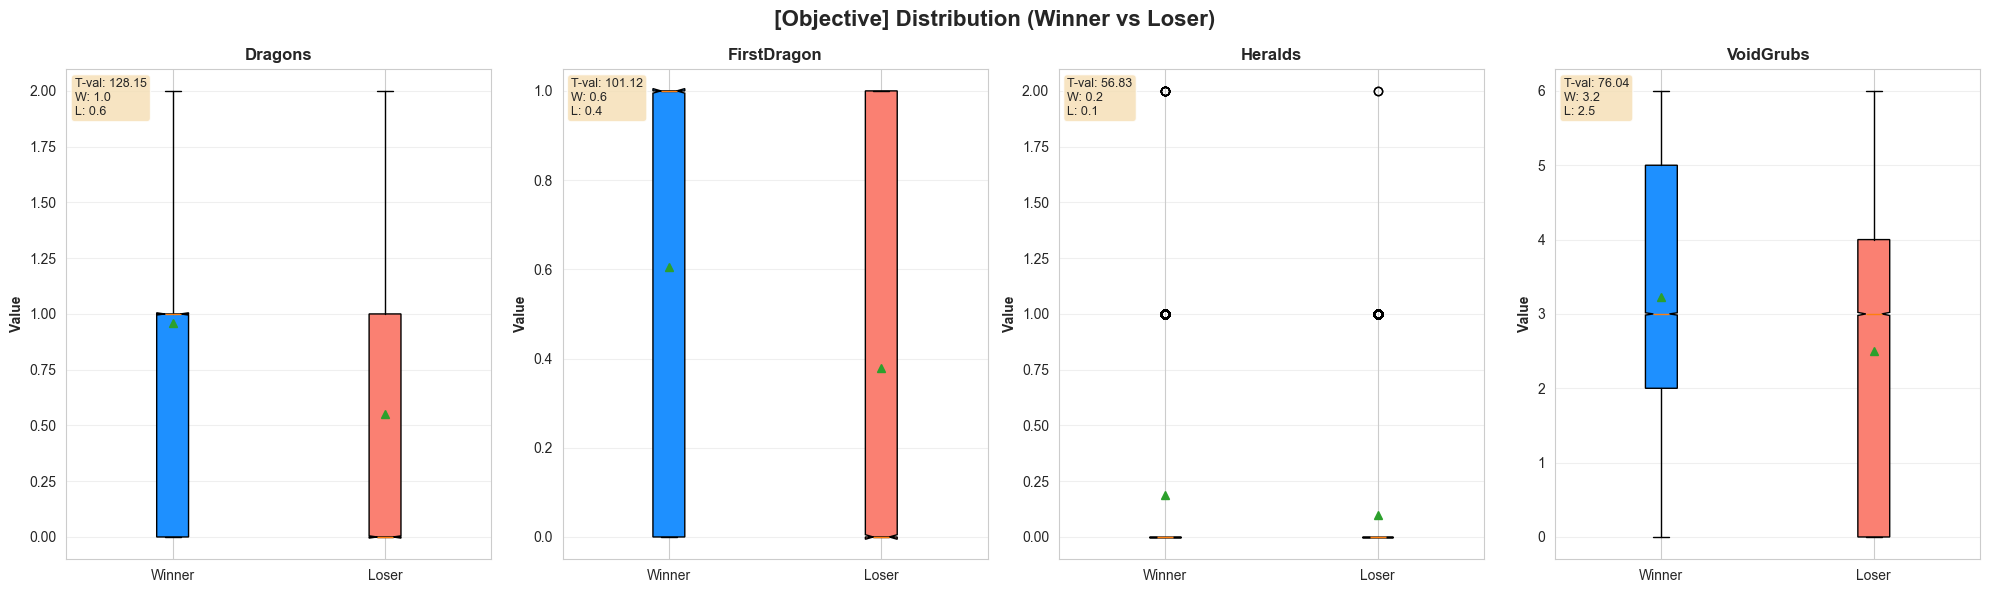

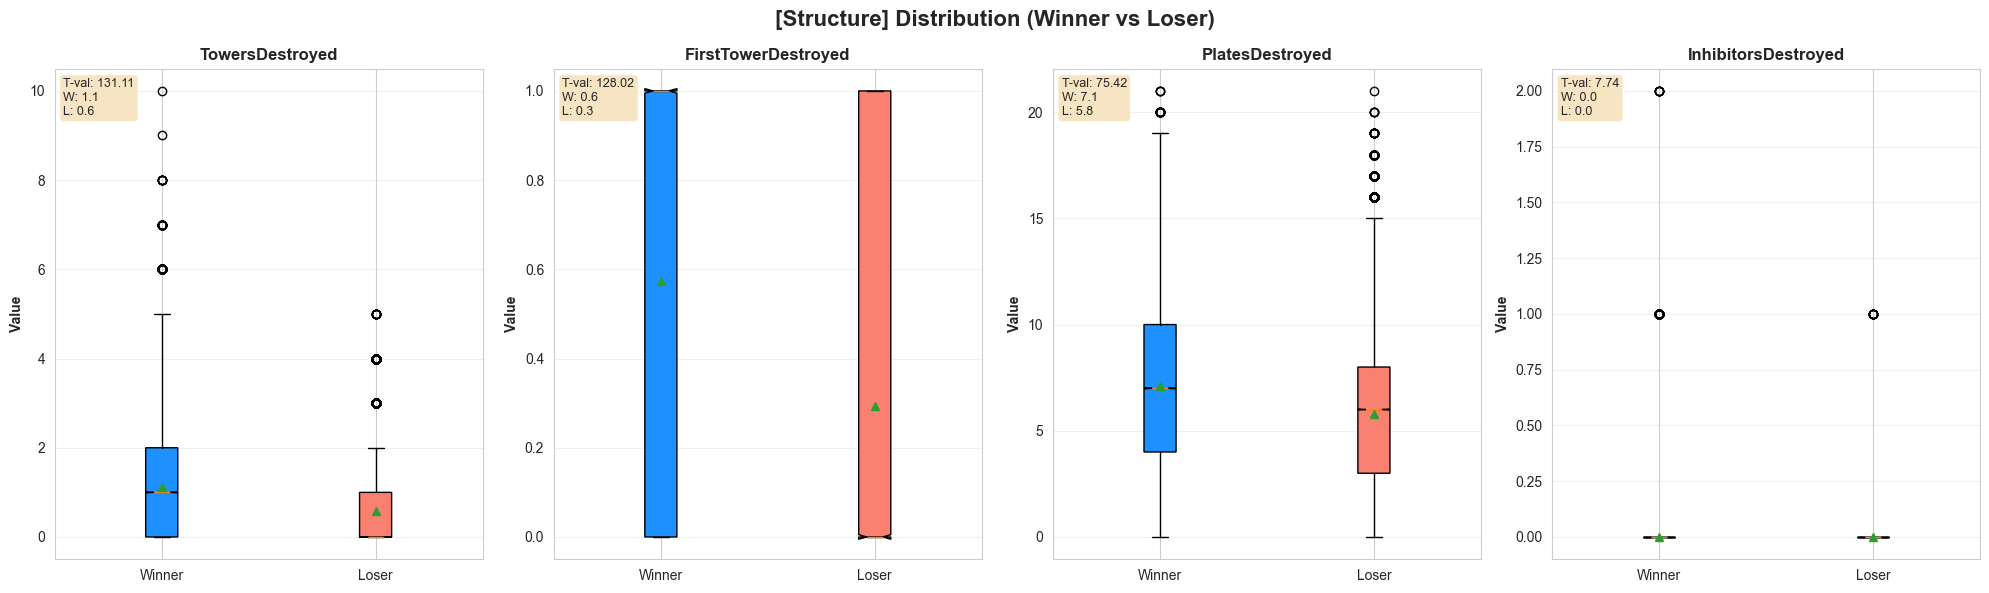

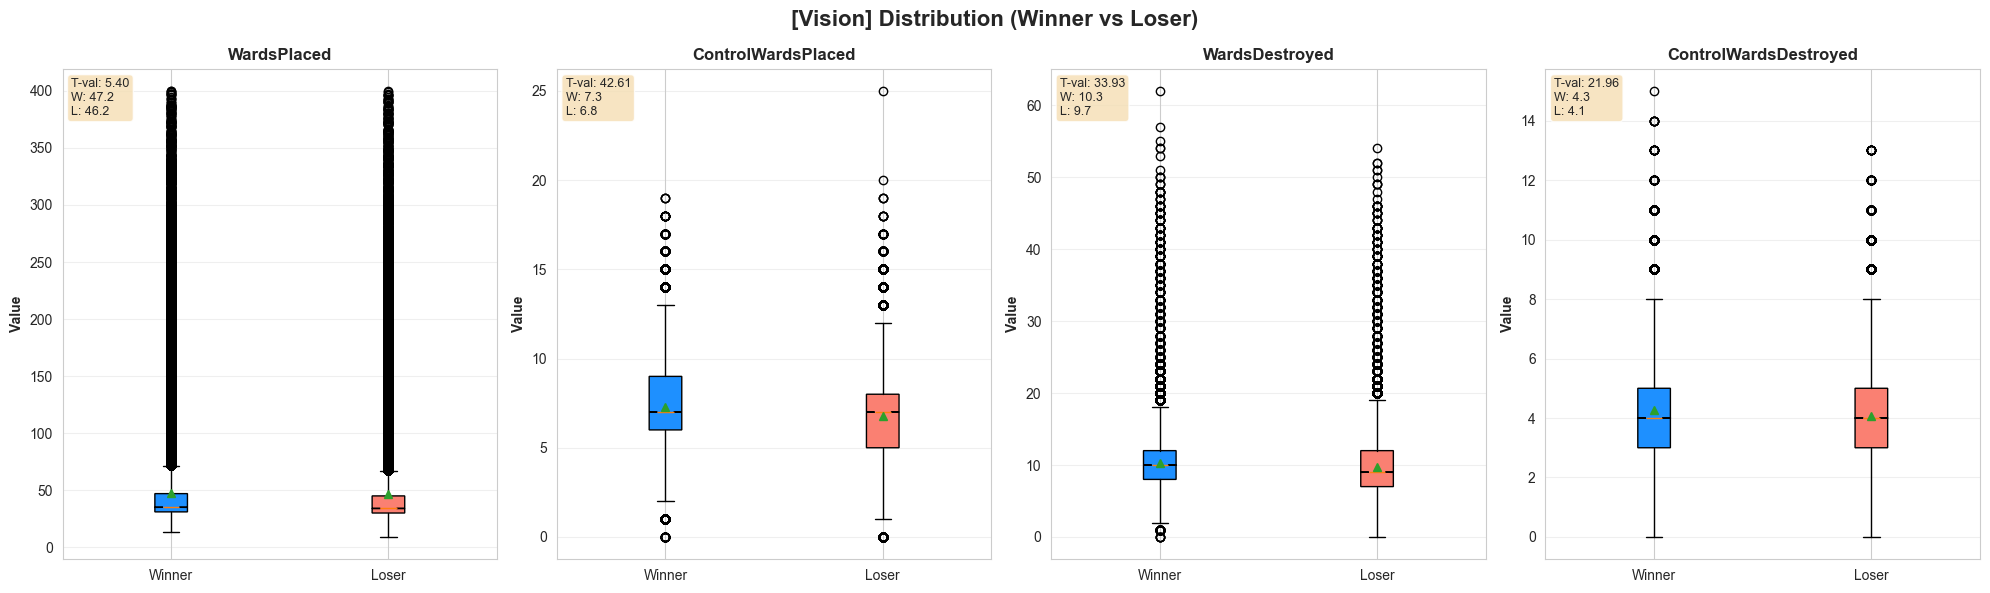

In [7]:
for category in categories:
    cat_vars = stats_df[stats_df['Category'] == category]
    n_vars = len(cat_vars)
    
    fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 6))
    if n_vars == 1:
        axes = [axes]
    
    fig.suptitle(f'[{category}] Distribution (Winner vs Loser)', fontsize=16, fontweight='bold')
    
    for idx, (_, row) in enumerate(cat_vars.iterrows()):
        ax = axes[idx]
        blue_col, red_col = row['blue_col'], row['red_col']
        
        winner_vals = np.where(df_clean['blueWins'] == 1, df_clean[blue_col], df_clean[red_col])
        loser_vals = np.where(df_clean['blueWins'] == 1, df_clean[red_col], df_clean[blue_col])
        
        bp = ax.boxplot([winner_vals, loser_vals], labels=['Winner', 'Loser'], 
                        patch_artist=True, notch=True, showmeans=True)
        bp['boxes'][0].set_facecolor('dodgerblue')
        bp['boxes'][1].set_facecolor('salmon')
        
        ax.set_title(row['Variable'], fontsize=12, fontweight='bold')
        ax.set_ylabel('Value', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        stats_text = f"T-val: {row['T-value']:.2f}\nW: {row['Winner_Mean']:.1f}\nL: {row['Loser_Mean']:.1f}"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    print(f"{'='*80}\n")

## 6. Correlation Heatmap

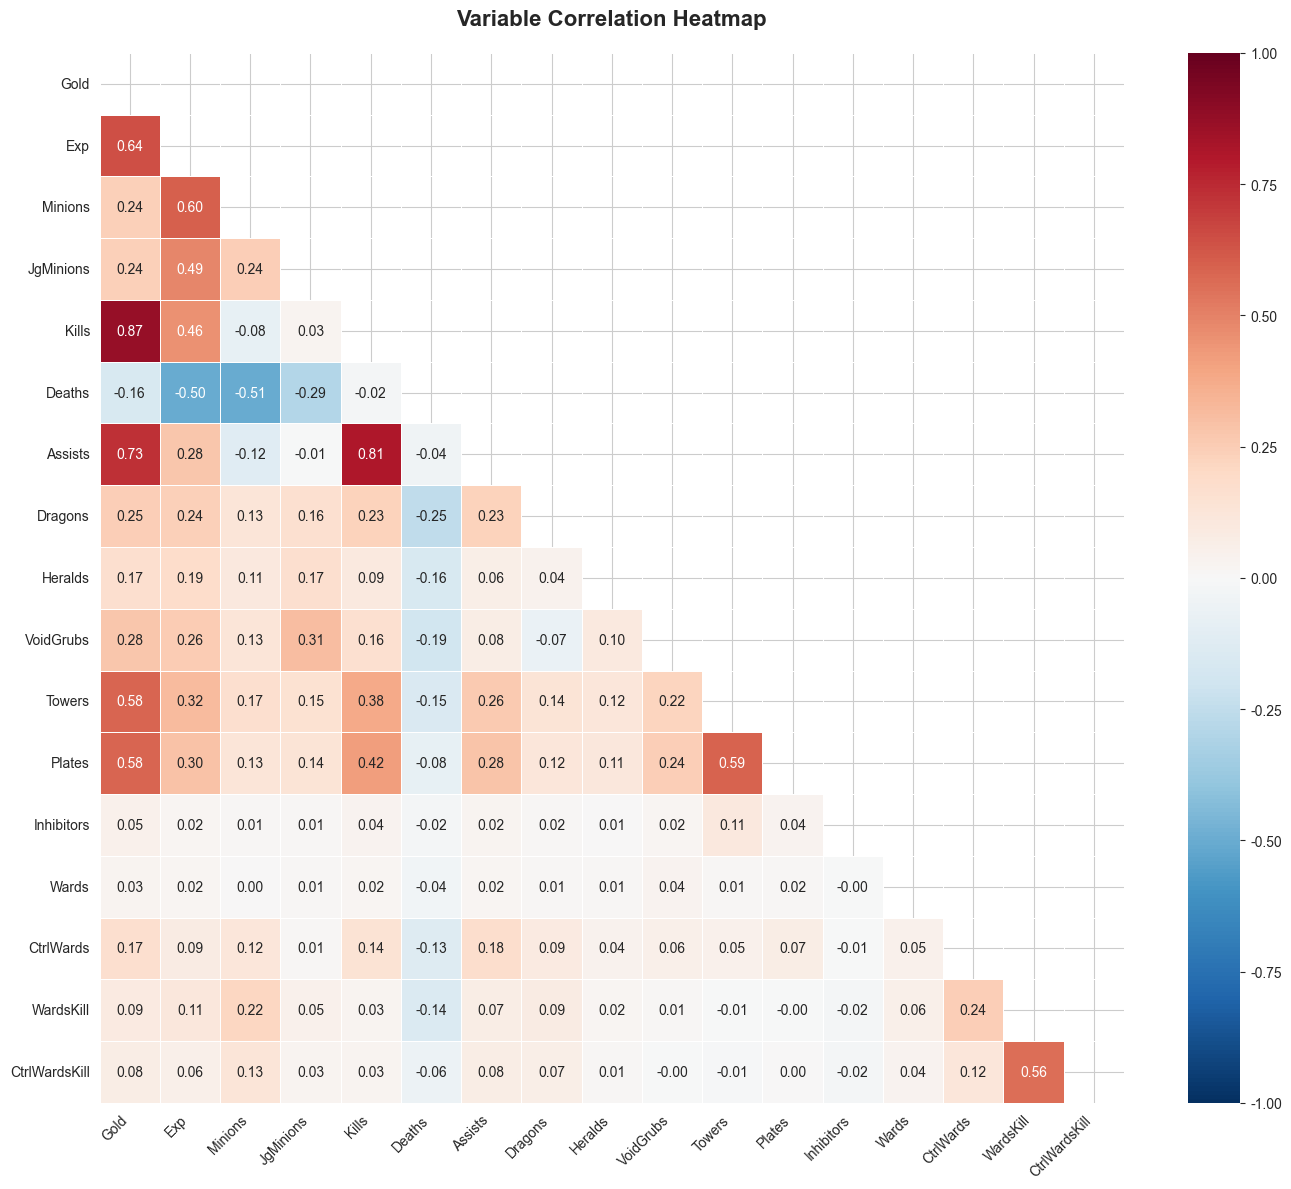

In [8]:
cont_vars = [
    'blueTotalGold', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled',
    'blueKills', 'blueDeaths', 'blueAssists',
    'blueDragons', 'blueHeralds', 'blueVoidGrubs',
    'blueTowersDestroyed', 'bluePlatesDestroyed', 'blueInhibitorsDestroyed',
    'blueWardsPlaced', 'blueControlWardsPlaced', 'blueWardsDestroyed', 'blueControlWardsDestroyed'
]

simple_names = [
    'Gold', 'Exp', 'Minions', 'JgMinions',
    'Kills', 'Deaths', 'Assists',
    'Dragons', 'Heralds', 'VoidGrubs',
    'Towers', 'Plates', 'Inhibitors',
    'Wards', 'CtrlWards', 'WardsKill', 'CtrlWardsKill'
]

corr_matrix = df_clean[cont_vars].corr()
corr_matrix.columns = simple_names
corr_matrix.index = simple_names

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Variable Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Data Cleaning Visualization

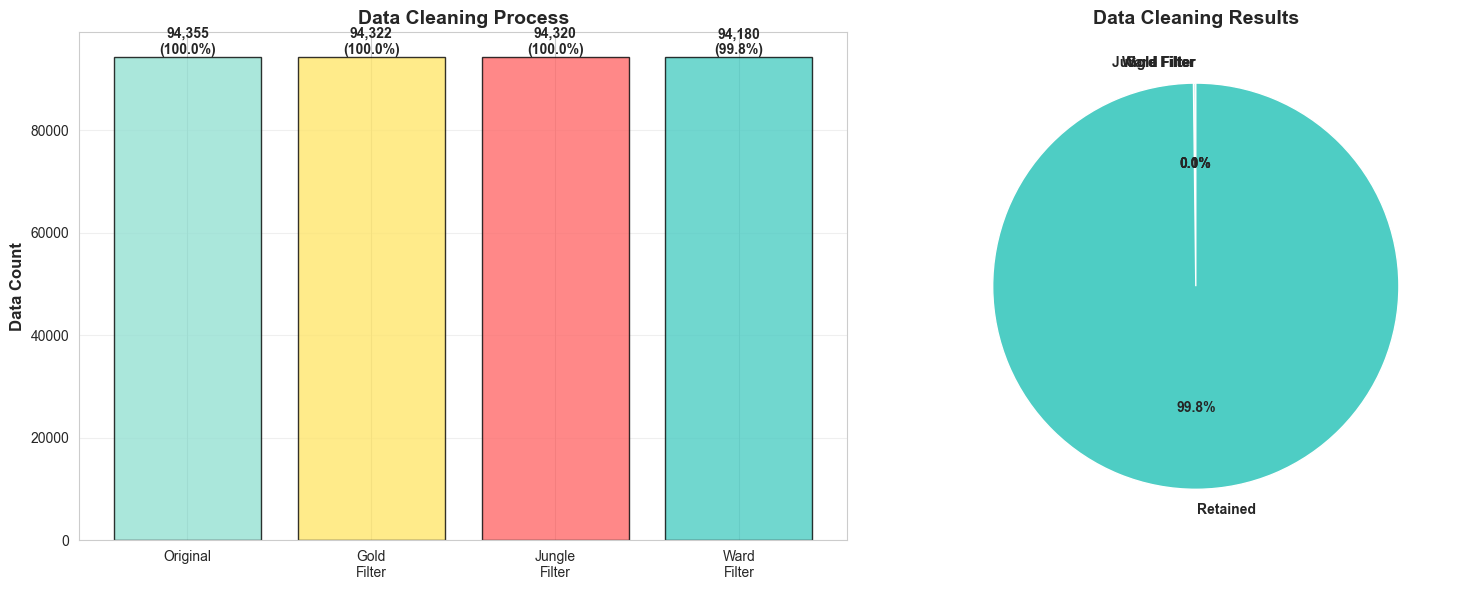

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
stages = ['Original', 'Gold\nFilter', 'Jungle\nFilter', 'Ward\nFilter']
counts = [start_len, start_len - gold_removed, 
          start_len - gold_removed - jungle_removed, len(df_clean)]
colors_stage = ['#95E1D3', '#FFE66D', '#FF6B6B', '#4ECDC4']

bars = ax1.bar(stages, counts, color=colors_stage, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Data Count', fontsize=12, fontweight='bold')
ax1.set_title('Data Cleaning Process', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count:,}\n({count/start_len*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# Pie chart
removed_data = {
    'Gold Filter': gold_removed,
    'Jungle Filter': jungle_removed,
    'Ward Filter': ward_removed,
    'Retained': len(df_clean)
}

ax2.pie(removed_data.values(), labels=removed_data.keys(),
        autopct='%1.1f%%', startangle=90,
        colors=['#FF6B6B', '#FFE66D', '#95E1D3', '#4ECDC4'],
        textprops={'fontweight': 'bold'})
ax2.set_title('Data Cleaning Results', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Real Match Validation (11 Matches)

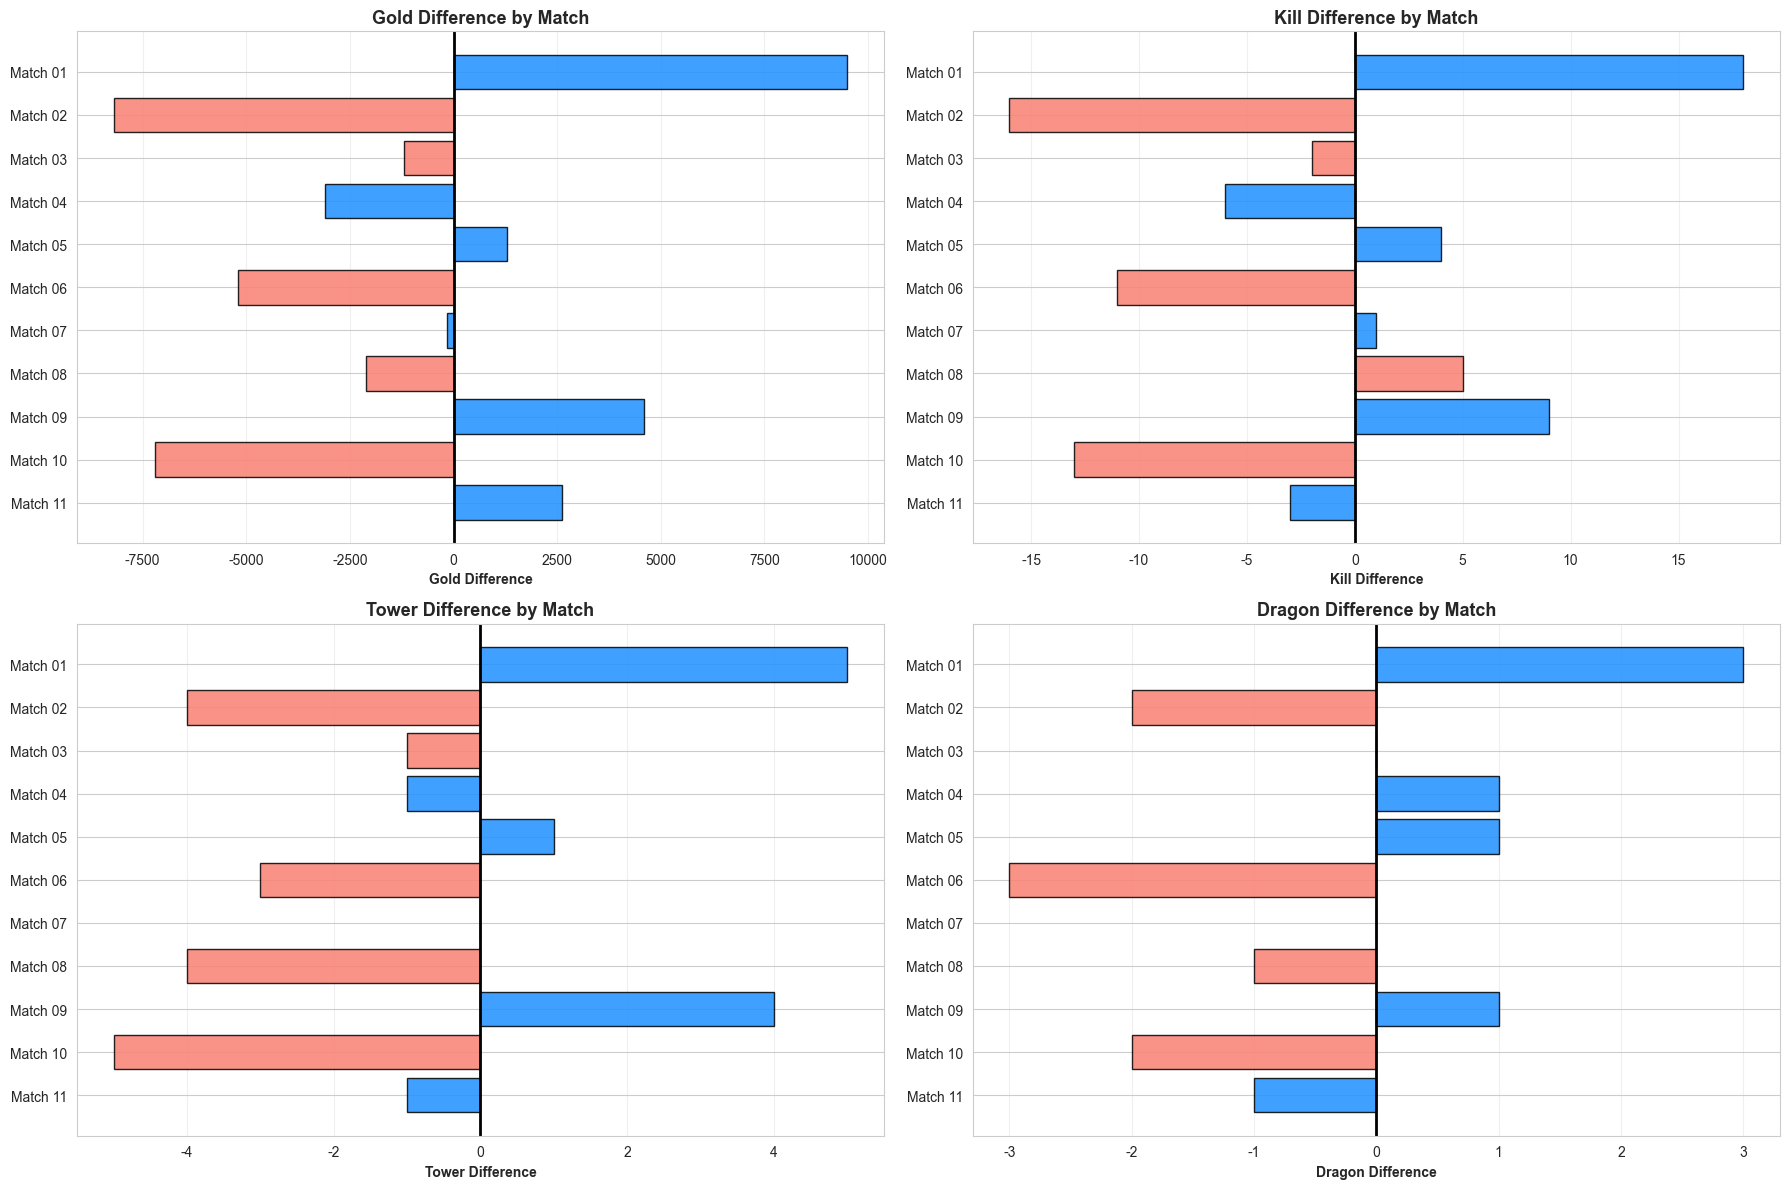


Real Match Validation (11 Matches)
Wins: 6 (54.5%)
Losses: 5 (45.5%)


In [10]:
my_matches = [
    {"Match": "Match 01", "blueWins": 1, "Diff_TotalGold": 9500, "Diff_Kills": 18, "Diff_TowersDestroyed": 5, "Diff_Dragons": 3},
    {"Match": "Match 02", "blueWins": 0, "Diff_TotalGold": -8200, "Diff_Kills": -16, "Diff_TowersDestroyed": -4, "Diff_Dragons": -2},
    {"Match": "Match 03", "blueWins": 0, "Diff_TotalGold": -1200, "Diff_Kills": -2, "Diff_TowersDestroyed": -1, "Diff_Dragons": 0},
    {"Match": "Match 04", "blueWins": 1, "Diff_TotalGold": -3100, "Diff_Kills": -6, "Diff_TowersDestroyed": -1, "Diff_Dragons": 1},
    {"Match": "Match 05", "blueWins": 1, "Diff_TotalGold": 1300, "Diff_Kills": 4, "Diff_TowersDestroyed": 1, "Diff_Dragons": 1},
    {"Match": "Match 06", "blueWins": 0, "Diff_TotalGold": -5200, "Diff_Kills": -11, "Diff_TowersDestroyed": -3, "Diff_Dragons": -3},
    {"Match": "Match 07", "blueWins": 1, "Diff_TotalGold": -150, "Diff_Kills": 1, "Diff_TowersDestroyed": 0, "Diff_Dragons": 0},
    {"Match": "Match 08", "blueWins": 0, "Diff_TotalGold": -2100, "Diff_Kills": 5, "Diff_TowersDestroyed": -4, "Diff_Dragons": -1},
    {"Match": "Match 09", "blueWins": 1, "Diff_TotalGold": 4600, "Diff_Kills": 9, "Diff_TowersDestroyed": 4, "Diff_Dragons": 1},
    {"Match": "Match 10", "blueWins": 0, "Diff_TotalGold": -7200, "Diff_Kills": -13, "Diff_TowersDestroyed": -5, "Diff_Dragons": -2},
    {"Match": "Match 11", "blueWins": 1, "Diff_TotalGold": 2610, "Diff_Kills": -3, "Diff_TowersDestroyed": -1, "Diff_Dragons": -1}
]

df_matches = pd.DataFrame(my_matches)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
colors_gold = ['dodgerblue' if w == 1 else 'salmon' for w in df_matches['blueWins']]

metrics = ['Diff_TotalGold', 'Diff_Kills', 'Diff_TowersDestroyed', 'Diff_Dragons']
titles = ['Gold Difference', 'Kill Difference', 'Tower Difference', 'Dragon Difference']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.barh(df_matches['Match'], df_matches[metric], 
            color=colors_gold, edgecolor='black', alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=2)
    ax.set_xlabel(title, fontweight='bold')
    ax.set_title(f'{title} by Match', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

wins = df_matches['blueWins'].sum()
print(f"\n{'='*60}")
print(f"Real Match Validation (11 Matches)")
print(f"{'='*60}")
print(f"Wins: {wins} ({wins/len(df_matches)*100:.1f}%)")
print(f"Losses: {len(df_matches)-wins} ({(len(df_matches)-wins)/len(df_matches)*100:.1f}%)")

## End of Visualization Appendix